<a href="https://colab.research.google.com/github/AryanSharma295/Personal-AI-Stylist/blob/main/AI_Fashion_Stylist_V1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# 1. Let's start with number 1: Checking our Python version
import sys
print(f"Python version: {sys.version}")

# 2. Coming to number 2: Saying hello to the project
print("AI Personal Stylist: Environment Setup Complete! 🚀")

Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
AI Personal Stylist: Environment Setup Complete! 🚀


In [4]:
# Install the library that lets us use YOLO (the detection brain)
!pip install ultralytics

from ultralytics import YOLO
print("AI Detection Tools Installed!")

AI Detection Tools Installed!



image 1/1 /content/test.jpg: 640x512 1 person, 73.1ms
Speed: 11.1ms preprocess, 73.1ms inference, 34.4ms postprocess per image at shape (1, 3, 640, 512)
Results saved to /content/runs/detect/predict


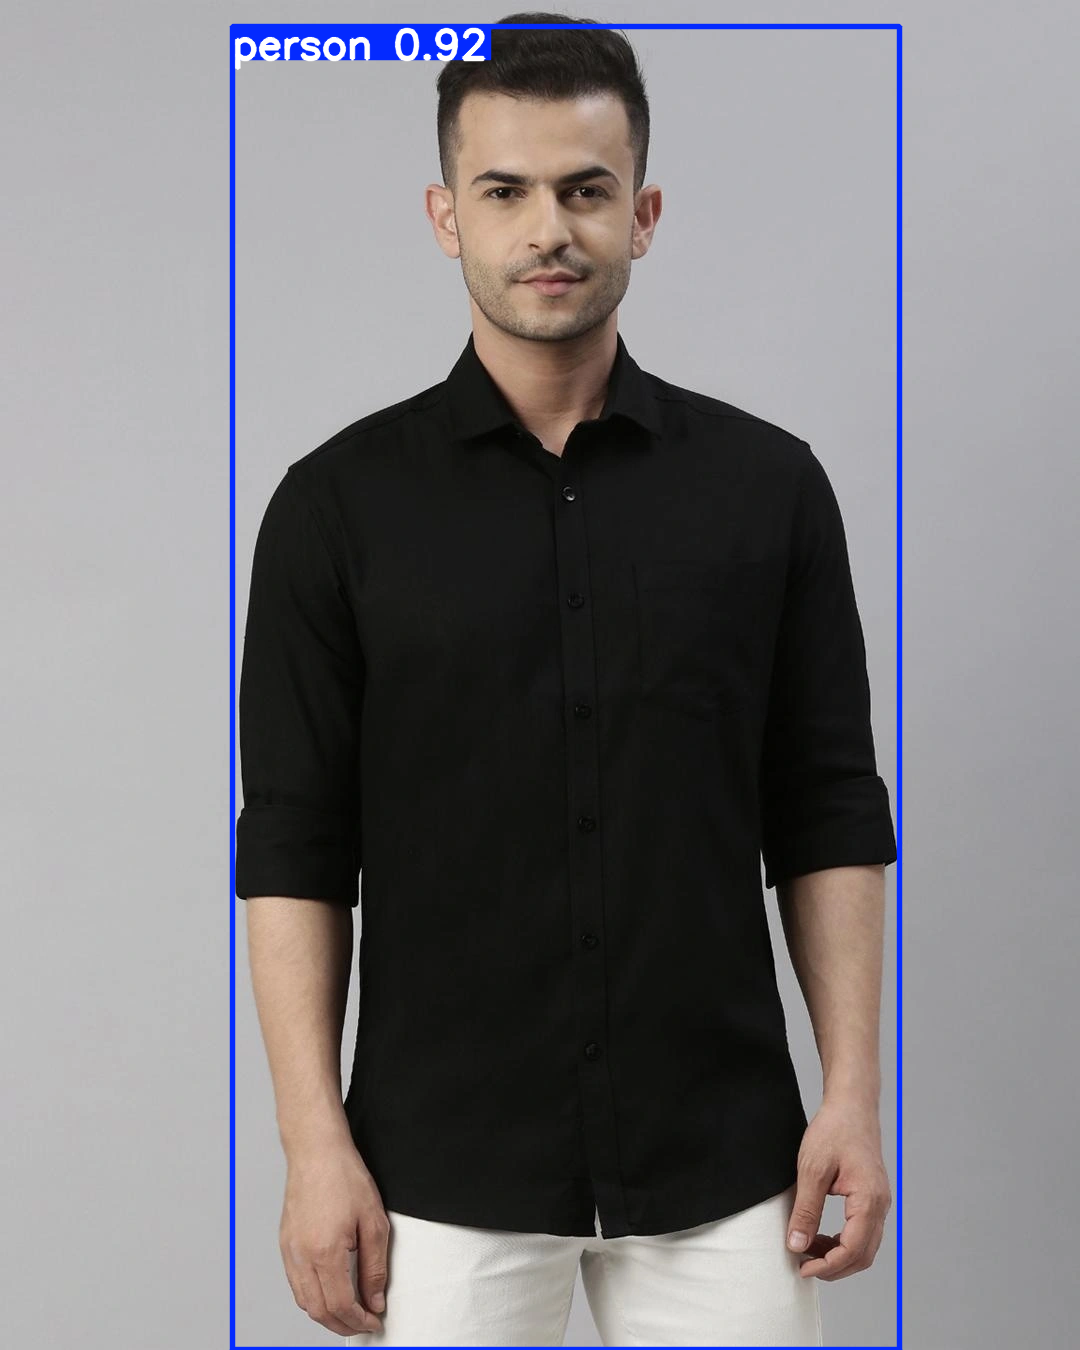

In [6]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow

# Load the Pre-trained Brain
model = YOLO('yolov8n.pt')

# Run the detection on your test image
results = model.predict(source='test.jpg', save=True, conf=0.5)

# Show the image with bounding boxes
for r in results:
    im_array = r.plot() # This draws the boxes
    cv2_imshow(im_array) # This displays it in Colab

In [7]:
from sklearn.cluster import KMeans

def get_color_of_item(image_path, box_coords):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Crop the image to just the clothing item
    x1, y1, x2, y2 = map(int, box_coords)
    crop = img[y1:y2, x1:x2]

    # Find the dominant color using K-Means
    pixels = crop.reshape(-1, 3)
    kmeans = KMeans(n_clusters=1, n_init=10)
    kmeans.fit(pixels)

    dominant_color = kmeans.cluster_centers_[0].astype(int)
    return dominant_color

# Let's try it!
for r in results:
    for box in r.boxes:
        coords = box.xyxy[0] # Get coordinates
        color = get_color_of_item('test.jpg', coords)
        print(f"Detected item color (RGB): {color}")

Detected item color (RGB): [95 91 88]
